# 02 — Modeling and Validation

**Evaluation protocol.** Train fits models. Validation drives every model/hyperparameter/threshold/calibration decision made in this notebook. **Test is not loaded in this notebook at all** — it is opened exactly once, in `03_final_test_evaluation.ipynb`, purely to report final numbers.

Two models only, both interpretable in how they're built:

- **Logistic Regression** — `ColumnTransformer` (scaling + one-hot encoding) inside an sklearn `Pipeline`, fit on train.
- **CatBoost** — native categorical-feature handling, `train` for fitting and `validation` as the early-stopping `eval_set`. No test leakage into training.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data, evaluation, modeling
from src.features import select_X_y

%matplotlib inline
pd.set_option("display.max_columns", 30)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

train = pd.read_csv(PROCESSED_DIR / "train.csv")
val = pd.read_csv(PROCESSED_DIR / "val.csv")
print("train:", train.shape, "val:", val.shape)
print("train churn rate:", train["churn_flag"].mean(), "| val churn rate:", val["churn_flag"].mean())

train: (4225, 22) val: (1409, 22)
train churn rate: 0.26532544378698225 | val churn rate: 0.2654364797728886


In [2]:
numeric_cols, categorical_cols = data.get_feature_columns(train)
feature_cols = numeric_cols + categorical_cols

X_train, y_train = select_X_y(train, feature_cols, data.TARGET)
X_val, y_val = select_X_y(val, feature_cols, data.TARGET)

## 1. Logistic Regression baseline

Class imbalance can sometimes be handled with `class_weight="balanced"`, but that is not assumed to help — it is compared against the unweighted model on validation PR-AUC, and only kept if it actually wins.

In [3]:
cw_result = modeling.choose_logreg_class_weight(
    X_train, y_train, X_val, y_val, numeric_cols, categorical_cols
)
cw_comparison = pd.DataFrame(
    {k: {"val_pr_auc": v["val_pr_auc"]} for k, v in cw_result["results"].items()}
).T
print(cw_comparison)
print("Chosen class_weight:", cw_result["best_class_weight"])

logreg_pipeline = cw_result["results"][cw_result["best_class_weight"]]["pipeline"]

          val_pr_auc
None        0.642162
balanced    0.642678
Chosen class_weight: balanced


In [4]:
logreg_val_proba = logreg_pipeline.predict_proba(X_val)[:, 1]
logreg_val_metrics = evaluation.classification_report_dict(y_val, logreg_val_proba, threshold=0.5)
logreg_val_metrics

{'threshold': 0.5,
 'roc_auc': 0.8363106771035159,
 'pr_auc': 0.6426775582971987,
 'precision': 0.5147826086956522,
 'recall': 0.7914438502673797,
 'f1': 0.6238145416227608,
 'tn': 756,
 'fp': 279,
 'fn': 78,
 'tp': 296}

**Coefficient inspection.** With one-hot encoding + scaling inside the pipeline, coefficients are still directly interpretable as the direction/magnitude of association with churn (in standardized-numeric / dummy-coded space).

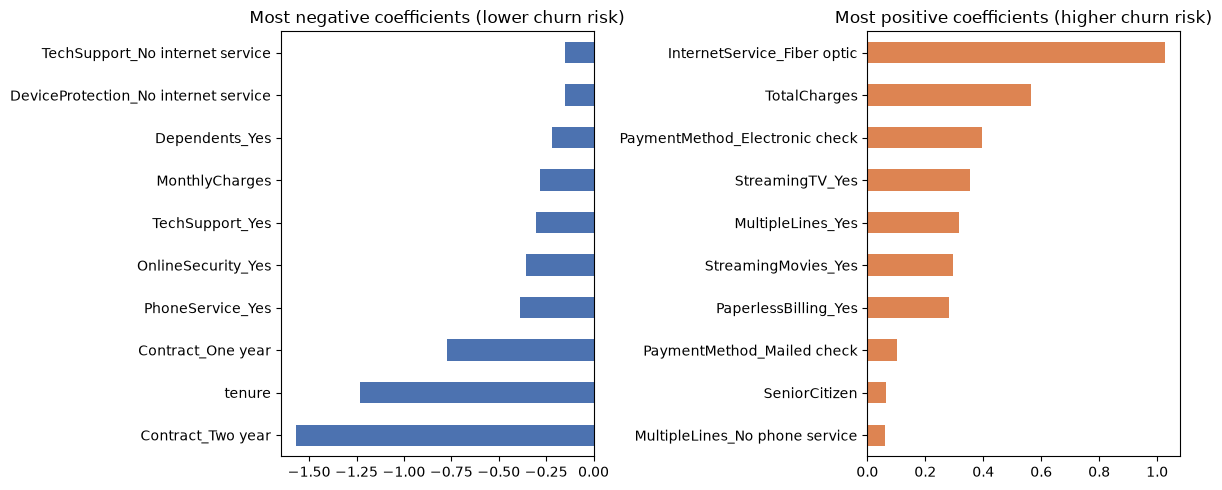

In [5]:
ohe = logreg_pipeline.named_steps["preprocess"].named_transformers_["cat"]
feature_names = numeric_cols + list(ohe.get_feature_names_out(categorical_cols))
coefs = pd.Series(logreg_pipeline.named_steps["model"].coef_[0], index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
coefs.head(10).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Most negative coefficients (lower churn risk)")
coefs.tail(10).plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Most positive coefficients (higher churn risk)")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "logreg_coefficients.png", dpi=150)
plt.show()

## 2. CatBoost: small hyperparameter grid, validation-driven

A small, meaningful grid over `depth` and `learning_rate` only. Each candidate is fit on train with validation as the early-stopping `eval_set` (`eval_metric="PRAUC"`, since churners are the minority class and ranking quality is what we ultimately care about). Selection is by validation PR-AUC — never test.

In [6]:
grid = [
    {"depth": 4, "learning_rate": 0.05},
    {"depth": 6, "learning_rate": 0.05},
    {"depth": 6, "learning_rate": 0.1},
    {"depth": 8, "learning_rate": 0.1},
]

grid_results = modeling.small_catboost_grid_search(
    X_train, y_train, X_val, y_val, feature_cols, categorical_cols, grid
)
grid_table = pd.DataFrame(
    [{**r["params"], "best_iteration": r["best_iteration"], "val_pr_auc": r["val_pr_auc"]} for r in grid_results]
)
grid_table.to_csv(TABLE_DIR / "catboost_grid_search.csv", index=False)
grid_table

,depth,learning_rate,best_iteration,val_pr_auc
0,4,0.05,192,0.652041
1,6,0.10,78,0.650383
2,8,0.10,31,0.644984
3,6,0.05,73,0.644537


In [7]:
best_params = grid_results[0]["params"]
print("Selected CatBoost params (by validation PR-AUC):", best_params)

Selected CatBoost params (by validation PR-AUC): {'depth': 4, 'learning_rate': 0.05}


**Class weighting for CatBoost.** As with Logistic Regression, we do not assume weighting the minority class helps — we compare against the unweighted best-params model on validation PR-AUC.

In [8]:
cat_unweighted = modeling.fit_catboost(
    X_train, y_train, X_val, y_val, feature_cols, categorical_cols, params=best_params
)
cat_unweighted_val_proba = cat_unweighted.predict_proba(X_val[feature_cols])[:, 1]
pr_auc_unweighted = evaluation.classification_report_dict(y_val, cat_unweighted_val_proba, 0.5)["pr_auc"]

churn_share = y_train.mean()
class_weights = [1.0, (1 - churn_share) / churn_share]
cat_weighted = modeling.fit_catboost(
    X_train, y_train, X_val, y_val, feature_cols, categorical_cols,
    params=best_params, class_weights=class_weights,
)
cat_weighted_val_proba = cat_weighted.predict_proba(X_val[feature_cols])[:, 1]
pr_auc_weighted = evaluation.classification_report_dict(y_val, cat_weighted_val_proba, 0.5)["pr_auc"]

print(f"Unweighted val PR-AUC: {pr_auc_unweighted:.4f}")
print(f"Weighted (class_weights={[round(c,2) for c in class_weights]}) val PR-AUC: {pr_auc_weighted:.4f}")

if pr_auc_weighted > pr_auc_unweighted:
    cat_model = cat_weighted
    cat_val_proba = cat_weighted_val_proba
    print("-> Using class-weighted CatBoost (higher validation PR-AUC).")
else:
    cat_model = cat_unweighted
    cat_val_proba = cat_unweighted_val_proba
    print("-> Using unweighted CatBoost (class weighting did not improve validation PR-AUC).")

Unweighted val PR-AUC: 0.6520
Weighted (class_weights=[1.0, np.float64(2.77)]) val PR-AUC: 0.6533
-> Using class-weighted CatBoost (higher validation PR-AUC).


## 3. Validation-set model comparison

In [9]:
logreg_val_row = {"model": "Logistic Regression", **evaluation.classification_report_dict(y_val, logreg_val_proba, 0.5)}
cat_val_row = {"model": "CatBoost", **evaluation.classification_report_dict(y_val, cat_val_proba, 0.5)}
val_comparison = pd.DataFrame([logreg_val_row, cat_val_row]).set_index("model")
val_comparison.to_csv(TABLE_DIR / "validation_model_comparison.csv")
val_comparison

,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,,
Logistic Regression,0.5,0.836311,0.642678,0.514783,0.791444,0.623815,756,279,78,296
CatBoost,0.5,0.839230,0.653307,0.506066,0.780749,0.614090,750,285,82,292


CatBoost is selected as the main model if it matches or exceeds Logistic Regression on **validation PR-AUC** (the primary model-selection signal for an imbalanced ranking problem) — ROC-AUC alone would understate how much minority-class ranking improves.

In [10]:
logreg_val_ranking = evaluation.ranking_table(y_val, logreg_val_proba)
logreg_val_ranking.insert(0, "model", "Logistic Regression")

cat_val_ranking = evaluation.ranking_table(y_val, cat_val_proba)
cat_val_ranking.insert(0, "model", "CatBoost")

val_ranking = pd.concat([logreg_val_ranking, cat_val_ranking], ignore_index=True)
val_ranking.to_csv(TABLE_DIR / "validation_ranking_comparison.csv", index=False)
val_ranking

,model,top_k_pct,n_contacted,churners_captured,precision_at_k,recall_at_k,lift_at_k
0,Logistic Regression,5.0,70,52,0.742857,0.139037,2.798625
1,Logistic Regression,10.0,141,103,0.730496,0.275401,2.752057
2,Logistic Regression,20.0,282,193,0.684397,0.516043,2.578384
3,CatBoost,5.0,70,59,0.842857,0.157754,3.175363
4,CatBoost,10.0,141,107,0.758865,0.286096,2.858934
5,CatBoost,20.0,282,190,0.673759,0.508021,2.538305


## 4. Probability calibration (fit on validation only)

We check whether raw CatBoost probabilities are well-calibrated on validation, and only apply Platt (sigmoid) calibration if it measurably improves the Brier score. The calibration map itself is fit on validation and is never touched by test data.

In [11]:
brier_before = evaluation.calibration_summary(y_val, cat_val_proba)
print("CatBoost validation calibration BEFORE calibration:", brier_before)

calibrated_model = modeling.calibrate_on_validation(cat_model, X_val[feature_cols], y_val, method="sigmoid")
cat_val_proba_calibrated = calibrated_model.predict_proba(X_val[feature_cols])[:, 1]
brier_after = evaluation.calibration_summary(y_val, cat_val_proba_calibrated)
print("CatBoost validation calibration AFTER sigmoid calibration:", brier_after)

CatBoost validation calibration BEFORE calibration: {'brier_score': 0.16591757276900546, 'log_loss': 0.49179781137163925}
CatBoost validation calibration AFTER sigmoid calibration: {'brier_score': 0.1376145059772262, 'log_loss': 0.4263697771693577}


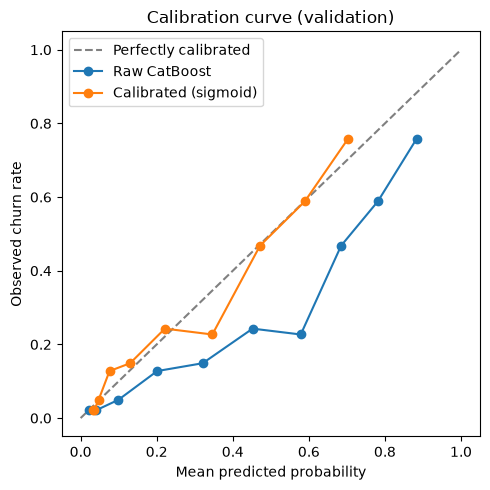

In [12]:
cal_curve_before = evaluation.calibration_table(y_val, cat_val_proba)
cal_curve_after = evaluation.calibration_table(y_val, cat_val_proba_calibrated)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.plot(cal_curve_before["mean_predicted_prob"], cal_curve_before["fraction_of_positives"], marker="o", label="Raw CatBoost")
ax.plot(cal_curve_after["mean_predicted_prob"], cal_curve_after["fraction_of_positives"], marker="o", label="Calibrated (sigmoid)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title("Calibration curve (validation)")
ax.legend()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "calibration_curve_validation.png", dpi=150)
plt.show()

In [13]:
use_calibrated = brier_after["brier_score"] < brier_before["brier_score"]
print("Use calibrated model for downstream probability-dependent decisions:", use_calibrated)

calibration_decision = {
    "brier_before": brier_before["brier_score"],
    "brier_after": brier_after["brier_score"],
    "log_loss_before": brier_before["log_loss"],
    "log_loss_after": brier_after["log_loss"],
    "use_calibrated": use_calibrated,
}
pd.Series(calibration_decision).to_csv(TABLE_DIR / "calibration_decision.csv")
calibration_decision

Use calibrated model for downstream probability-dependent decisions: True


{'brier_before': 0.16591757276900546,
 'brier_after': 0.1376145059772262,
 'log_loss_before': 0.49179781137163925,
 'log_loss_after': 0.4263697771693577,
 'use_calibrated': True}

## 5. Persist the final chosen pipeline

The model trained on **train only**, with validation used for early stopping and (if it won on Brier score) for calibration, is the final artifact evaluated once on test in the next notebook. We do **not** refit on train+validation: refitting would train a different model than the one the calibration map was fit against, which would silently break the calibration guarantee. With 4,225 training rows already available, the marginal value of folding in validation is small compared to that risk.

In [14]:
import joblib

final_model = calibrated_model if use_calibrated else cat_model
joblib.dump(final_model, MODEL_DIR / "catboost_final.pkl")
joblib.dump(cat_model, MODEL_DIR / "catboost_uncalibrated.pkl")
joblib.dump(logreg_pipeline, MODEL_DIR / "logreg_final.pkl")

with open(MODEL_DIR / "feature_columns.txt", "w") as f:
    f.write("\n".join(feature_cols))

print("Saved final CatBoost pipeline (calibrated=%s) and Logistic Regression pipeline to %s" % (use_calibrated, MODEL_DIR))

Saved final CatBoost pipeline (calibrated=True) and Logistic Regression pipeline to C:\Users\grosh\subscription-churn-model\models


## Summary

- Logistic Regression and CatBoost were both fit on train only; every model, hyperparameter, class-weighting, and calibration decision above used validation data exclusively.
- CatBoost's small `depth` x `learning_rate` grid was selected by validation PR-AUC, with early stopping against the validation `eval_set` (test was never involved).
- Class weighting was tested, not assumed, for both models.
- Calibration was fit on validation only and adopted only if it improved the validation Brier score.
- The final artifacts (`models/catboost_final.pkl`, `models/logreg_final.pkl`) are evaluated exactly once, on test, in `03_final_test_evaluation.ipynb`.